# CIFAR-10 Fully Connected Network (FCN) Implementation

This document contains the implementation of a Fully Connected Network (FCN) for classifying images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. The FCN architecture will be designed to process the flattened pixel values of the images and output class probabilities.

In [17]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [18]:
# imports
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10

from keras import backend as K
print(K.backend())

tensorflow


## Loading the CIFAR-10 dataset

The dataset is loaded using the `cifar10.load_data()` function, which returns the training and testing data. The training data consists of 50,000 images and their corresponding labels, while the testing data consists of 10,000 images and their corresponding labels. Each image is a 32x32 pixel color image with three channels (RGB), and each label is an integer representing the class of the image. The classes in the CIFAR-10 dataset are:
- 0: airplane
- 1: automobile
- 2: bird
- 3: cat
- 4: deer
- 5: dog
- 6: frog
- 7: horse
- 8: ship
- 9: truck

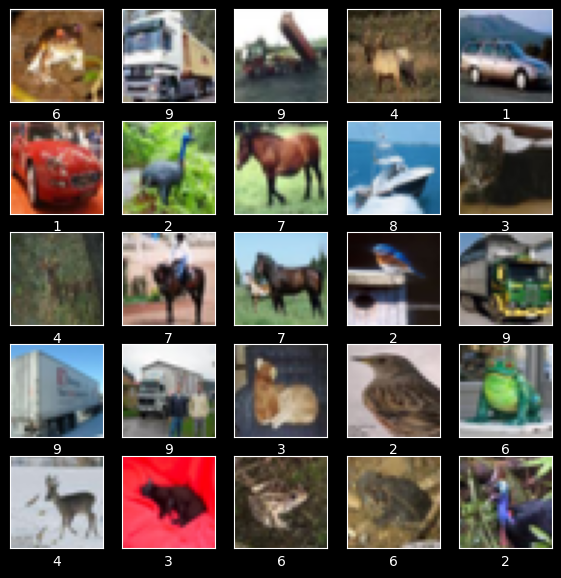

In [19]:
# Few example images from the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i][0])
plt.show()

## Building the Fully Connected Network (FCN)

The FCN architecture consists of several layers:
1. **Input Layer**: Accepts the 32x32x3 images.
2. **Flatten Layer**: Flattens the input images into a 1D array of 3072 elements (32*32*3).
3. **Dense Layer 1**: A fully connected layer with 512 neurons and ReLU activation.
4. **Dense Layer 2**: A fully connected layer with 256 neurons and ReLU activation.
5. **Dense Layer 3**: A fully connected layer with 128 neurons and ReLU activation.
6. **Output Layer**: A fully connected layer with 10 neurons (one for each class) and softmax activation to output class probabilities.

In [20]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn")

## Model Summary and Compilation

When we take a look at the model summary, we can see the number of parameters in each layer. In total, the model has 1,738,890 trainable parameters.

In [21]:
model.summary()

Model: "cifar10_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Before training the model, we need to preprocess the data. The pixel values of the images are normalized to the range [0, 1] by dividing by 255. Additionally, the labels are converted to one-hot encoded vectors using `keras.utils.to_categorical()`, which is necessary for multi-class classification with categorical cross-entropy loss.

In [29]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Now we compile the model using the Adam optimizer with a learning rate of 0.001, and we use categorical cross-entropy as the loss function, Label_smoothing is set to 0.1 to help prevent overfitting. It affects the loss function by smoothing the labels, which can improve generalization and reduce overfitting. The metric used for evaluation during training is accuracy.

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

## Training the Model

The model is trained for 20 epochs with a batch size of 128. During training, 20% of the training data is used for validation to monitor the model's performance on unseen data. The training history, including loss and accuracy for both training and validation sets, is stored in the `history` variable.

In [24]:
history = model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.2)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3010 - loss: 2.0146 - val_accuracy: 0.3466 - val_loss: 1.9056
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3846 - loss: 1.8357 - val_accuracy: 0.4096 - val_loss: 1.8047
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4130 - loss: 1.7750 - val_accuracy: 0.4229 - val_loss: 1.7635
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4363 - loss: 1.7279 - val_accuracy: 0.4365 - val_loss: 1.7325
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.4541 - loss: 1.6872 - val_accuracy: 0.4505 - val_loss: 1.7228
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4673 - loss: 1.6650 - val_accuracy: 0.4528 - val_loss: 1.7135
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4811 - loss: 1.6329 - val_accuracy: 0.4578 - val_loss: 1.6949
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4947 - loss: 1.6089 - val_acc

## Evaluating the Model

Using the stored history, we can plot the training and validation loss over epochs to visualize the model's learning progress. After trying out Adam as the optimizer, we noticed that the validation loss seems to do alot more zig-zagging than with SGD, which is probably due to the fact that Adam adapts the learning rate during training, which can lead to more fluctuations in the loss values. Overall, Adam optimizer provided better results.

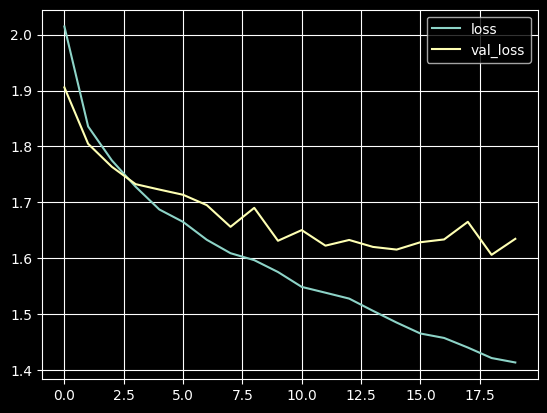

In [30]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss", "val_loss"])
plt.grid()
plt.show()

In [26]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.4957 - loss: 1.6330
Test loss: 1.6329832077026367
Test accuracy: 0.49570000171661377


During the training process, we can see that the model achieved almost 60% accuracy on the test set, which is a decent result for a simple FCN architecture on the CIFAR-10 dataset. However, on the evaluation of the model, we can see that the test loss is around 1.6 and the test accuracy is around 0.49 which means there is room for small improvements.

## Visualizing Predictions

Finally, we can visualize some of the predictions made by the model on the test set. For each of the first 10 images in the test set, we display the image along with its true label and the predicted probabilities for each class. The predicted class is determined by taking the argmax of the predicted probabilities.

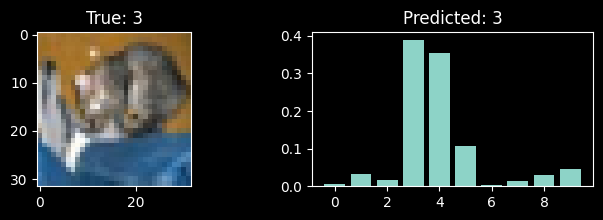

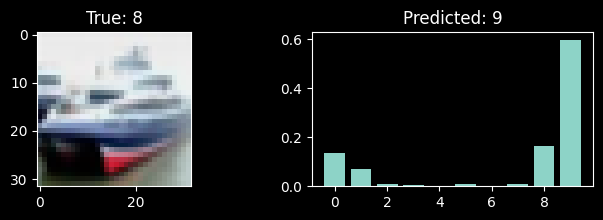

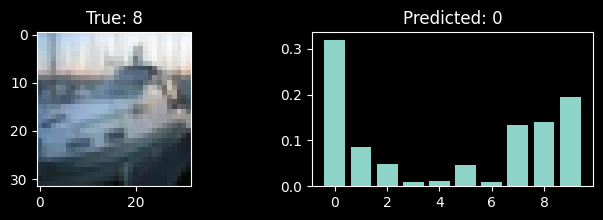

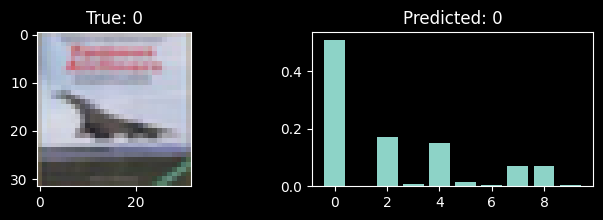

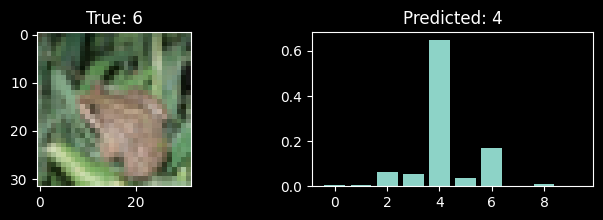

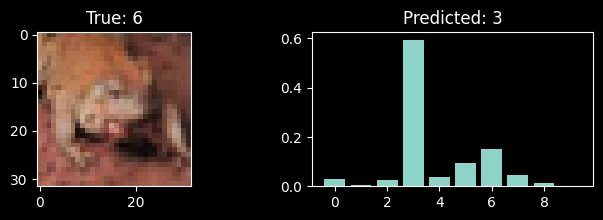

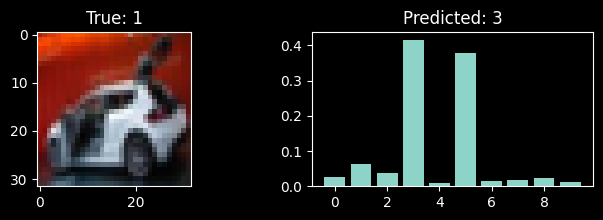

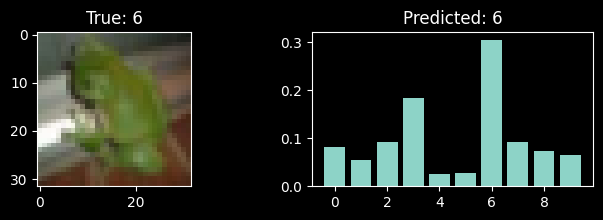

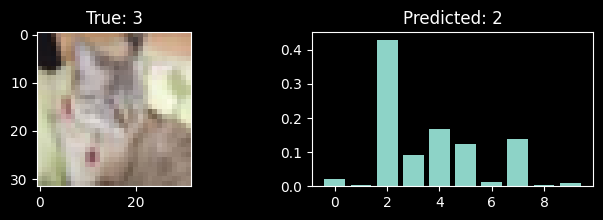

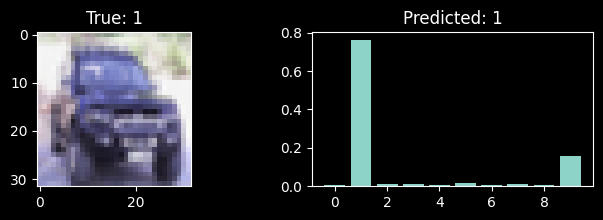

In [27]:
x = x_test
y = model(x)
start = 0

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k])
    plt.title(f"True: {np.argmax(y_test[start+k])}")
    plt.subplot(1,2,2)
    plt.bar(range(10), y[start+k])
    plt.title(f"Predicted: {np.argmax(y[start+k])}")
    plt.show()